# Text Cleaning and Chunk Engineering

This notebook prepares the extracted protocol text for retrieval. We will clean only clear PDF extraction artefacts, preserve document and page provenance, and compare sensible chunking strategies before creating embeddings.

The goal is to create chunks that are small enough for precise retrieval but large enough to retain useful context.

## 1. Load the validated page corpus

Day 1 produced a validated page-level representation of the five protocol documents. We will load that processed dataset rather than extracting the PDFs again.

This gives Day 2 a stable starting point while preserving the original document IDs, filenames, page numbers and extracted text.

In [1]:
from pathlib import Path

import pandas as pd


# Load the validated page-level dataset created on Day 1
pages_path = Path("../data/processed/corpus_pages.jsonl")
pages_df = pd.read_json(pages_path, lines=True)

# Confirm that the expected dataset was loaded
print("Dataset shape:", pages_df.shape)
print("Documents:", pages_df["document_id"].nunique())
print("Pages:", len(pages_df))

# Check that the important provenance fields are still complete
metadata_columns = [
    "document_id",
    "document_name",
    "filename",
    "page_number",
]

print("\nMissing provenance:")
print(pages_df[metadata_columns].isna().sum())

# Preview the structure without printing the full page text
print("\nColumns:")
print(pages_df.columns.tolist())

Dataset shape: (52, 7)
Documents: 5
Pages: 52

Missing provenance:
document_id      0
document_name    0
filename         0
page_number      0
dtype: int64

Columns:
['document_id', 'document_name', 'filename', 'page_number', 'character_count', 'text', 'token_count']


## 2. Inspect text extraction artefacts

Day 1 identified several formatting artefacts introduced during PDF extraction, including split words, line-break hyphenation and repeated page headers or footers.

Before cleaning the text, we will inspect how often these patterns occur across the full corpus. The aim is to make conservative cleaning decisions that remove obvious extraction noise without changing legitimate protocol language.

In [2]:
import re

# Look for words that appear split around a hyphen, such as "predic - tive"
split_hyphen_pattern = re.compile(r"\b\w+\s+-\s+\w+\b")

# Look for running page labels such as "Page 9 of 15"
page_label_pattern = re.compile(
    r"\bPage\s+\d+\s+of\s+\d+\b",
    flags=re.IGNORECASE
)

# Collect examples of split-word hyphenation
split_hyphen_examples = []

for text in pages_df["text"]:
    split_hyphen_examples.extend(
        split_hyphen_pattern.findall(text)
    )

print("Split-hyphen examples found:", len(split_hyphen_examples))

print("\nExample split words:")
for example in split_hyphen_examples[:15]:
    print("-", example)

# Count pages containing an extracted page label
pages_with_page_labels = pages_df[
    pages_df["text"].str.contains(
        page_label_pattern,
        na=False
    )
]

print(
    "\nPages containing 'Page X of Y' labels:",
    len(pages_with_page_labels)
)

print("\nDocuments containing these labels:")
print(
    pages_with_page_labels["document_name"]
    .value_counts()
)

Split-hyphen examples found: 327

Example split words:
- coun
-
selling
- effi -
cacy
- prog
-
ress
- propor -
tions
- inter -
vention
- partic
-
ipants
- anal
-
yses
- question
-
naires
- esti
-
mation
- recruit
-
ment
- inter -
vention
- assess
-
ments
- inter -
vention
- Institu
-
tional
- refer -
ence

Pages containing 'Page X of Y' labels: 23

Documents containing these labels:
document_name
INTEGRA    10
THP_TA      7
LISTEN      6
Name: count, dtype: int64


## 3. Inspect split-word patterns more closely

Split-word artefacts occur frequently across the corpus, but not every hyphen should automatically be removed. Some terms may be genuinely hyphenated, while others were split only because of PDF line wrapping.

We will inspect the raw text around several examples before deciding on a cleaning rule.

In [3]:
# Collect a few split-hyphen matches together with their surrounding text
split_context_examples = []

for _, row in pages_df.iterrows():
    text = row["text"]

    for match in split_hyphen_pattern.finditer(text):
        # Capture a small amount of text before and after the match
        start = max(0, match.start() - 50)
        end = min(len(text), match.end() + 50)

        split_context_examples.append(
            {
                "document": row["document_name"],
                "page": row["page_number"],
                "match": match.group(),
                "context": text[start:end],
            }
        )

# Show only a small sample so the notebook output stays readable
for example in split_context_examples[:10]:
    print(
        f"{example['document']} | "
        f"Page {example['page']} | "
        f"{example['match']}"
    )

    # repr() makes spaces and line breaks easier to inspect
    print(repr(example["context"]))
    print()

CERTAIN | Page 1 | coun
-
selling
'\nphysicians may deliver repeated face-\n to-\n face coun\n-\nselling services.\n ► The inclusion criteria include SLT u'

CERTAIN | Page 2 | effi -
cacy
'nths.11 21 There are, however, little data on the effi -\ncacy and effectiveness of such intervention combined \n'

CERTAIN | Page 4 | prog
-
ress
' \nsupport and ‘Arrange’ a follow-\n up to check on prog\n-\nress. This will conclude with their enrolment to recei'

CERTAIN | Page 4 | propor -
tions
'e \nsample size was calculated based on estimating propor -\ntions with a specified level of precision at the 95% le'

CERTAIN | Page 5 | inter -
vention
' the allocation of participants to the respective inter -\nvention arm. The independent staff member will assign \na '

CERTAIN | Page 5 | partic
-
ipants
'eline and end-\n point data will be collected from partic\n-\nipants at UPHC using surveys in paper format. This will '

CERTAIN | Page 5 | anal
-
yses
're lost to follow-\n up will also be reported

## 4. Apply conservative text cleaning

The inspection confirmed that many words were incorrectly split across PDF line boundaries, with the hyphen appearing separately from both parts of the word.

We will repair only this clearly identifiable pattern and preserve the original extracted text in a separate column. Genuine hyphenated terms will not be modified by this rule.

In [4]:
# Match words where a detached hyphen was introduced across a PDF line break
detached_word_break_pattern = re.compile(
    r"\b([A-Za-z]{2,})(?:[ \t]+|\n[ \t]*)-[ \t]*\n[ \t]*([A-Za-z]{2,})\b"
)


def clean_pdf_text(text):
    """Apply only conservative, well-understood PDF text fixes."""

    # Replace non-breaking spaces with normal spaces
    cleaned = text.replace("\u00a0", " ")

    # Repair split words such as "inter -\nvention" -> "intervention"
    cleaned = detached_word_break_pattern.sub(r"\1\2", cleaned)

    return cleaned


# Keep the raw text and create a separate cleaned version
pages_df["clean_text"] = pages_df["text"].apply(clean_pdf_text)

# Count how many clear split-word artefacts the rule can repair
total_repairs = sum(
    len(detached_word_break_pattern.findall(text))
    for text in pages_df["text"]
)

pages_changed = sum(
    bool(detached_word_break_pattern.search(text))
    for text in pages_df["text"]
)

print("Split-word repairs:", total_repairs)
print("Pages affected:", pages_changed)

# Test the rule on examples we already inspected
test_examples = [
    "coun\n-\nselling",
    "effi -\ncacy",
    "prog\n-\nress",
    "follow-\n up",
]

print("\nCleaning examples:\n")

for example in test_examples:
    print(repr(example), "->", repr(clean_pdf_text(example)))

Split-word repairs: 319
Pages affected: 30

Cleaning examples:

'coun\n-\nselling' -> 'counselling'
'effi -\ncacy' -> 'efficacy'
'prog\n-\nress' -> 'progress'
'follow-\n up' -> 'follow-\n up'


## 5. Validate the text cleaning

The conservative cleaning rule repaired most of the clearly broken split words while leaving ambiguous hyphenated terms unchanged.

We will now inspect the remaining patterns and compare raw and cleaned text examples to make sure the cleaning improved extraction quality without making unnecessary changes.

In [5]:
# Check which broad split-hyphen patterns remain after cleaning
remaining_split_examples = []

for text in pages_df["clean_text"]:
    remaining_split_examples.extend(
        split_hyphen_pattern.findall(text)
    )

print("Remaining split-hyphen patterns:", len(remaining_split_examples))

print("\nRemaining examples:")
for example in remaining_split_examples[:20]:
    print("-", example)


# Show a few real before-and-after examples from pages that changed
changed_pages = pages_df[
    pages_df["text"] != pages_df["clean_text"]
]

print("\nPages changed:", len(changed_pages))
print("\nBefore-and-after examples:\n")

for _, row in changed_pages.head(3).iterrows():
    raw_text = row["text"]
    clean_text = row["clean_text"]

    # Find the first repaired pattern on this page
    match = detached_word_break_pattern.search(raw_text)

    if match:
        start = max(0, match.start() - 50)
        end = min(len(raw_text), match.end() + 50)

        raw_preview = raw_text[start:end]
        clean_preview = clean_pdf_text(raw_preview)

        print(
            f"{row['document_name']} | "
            f"Page {row['page_number']}"
        )

        print("RAW:")
        print(repr(raw_preview))

        print("\nCLEANED:")
        print(repr(clean_preview))

        print("\n" + "=" * 70 + "\n")

Remaining split-hyphen patterns: 8

Remaining examples:
- Health - Hyderabad
- tion - Quality
- PHFI - Indian
- ee - C
- u -
ation
- fellow - Facultad
- a - C
- 5 - Level

Pages changed: 41

Before-and-after examples:

CERTAIN | Page 1
RAW:
'\nphysicians may deliver repeated face-\n to-\n face coun\n-\nselling services.\n ► The inclusion criteria include SLT u'

CLEANED:
'\nphysicians may deliver repeated face-\n to-\n face counselling services.\n ► The inclusion criteria include SLT u'


CERTAIN | Page 2
RAW:
'nths.11 21 There are, however, little data on the effi -\ncacy and effectiveness of such intervention combined \n'

CLEANED:
'nths.11 21 There are, however, little data on the efficacy and effectiveness of such intervention combined \n'




## 6. Remove page-number boilerplate

Some extracted pages contain running labels such as `Page 9 of 15`. The real page number is already preserved separately in our metadata, so these labels do not add useful retrieval information.

We will remove only this clearly identifiable boilerplate and leave other headers, references and document content unchanged unless later analysis shows they are causing retrieval problems.

In [6]:
# Match running page labels such as "Page 9 of 15"
page_label_pattern = re.compile(
    r"\bPage\s+\d+\s+of\s+\d+\b",
    flags=re.IGNORECASE
)


def clean_pdf_text(text):
    """Apply conservative, well-understood PDF text fixes."""

    # Replace non-breaking spaces with normal spaces
    cleaned = text.replace("\u00a0", " ")

    # Repair split words such as "inter -\nvention" -> "intervention"
    cleaned = detached_word_break_pattern.sub(r"\1\2", cleaned)

    # Remove page labels because page provenance is stored separately
    cleaned = page_label_pattern.sub("", cleaned)

    return cleaned


# Always rebuild cleaned text from the original extraction
pages_df["clean_text"] = pages_df["text"].apply(clean_pdf_text)

# Check whether any page labels remain
remaining_page_labels = pages_df[
    pages_df["clean_text"].str.contains(
        page_label_pattern,
        na=False
    )
]

print(
    "Pages with page labels before cleaning:",
    pages_df["text"].str.contains(page_label_pattern, na=False).sum()
)

print(
    "Pages with page labels after cleaning:",
    len(remaining_page_labels)
)

# Confirm that every page still contains text
empty_clean_pages = (
    pages_df["clean_text"].str.strip().eq("")
).sum()

print("Empty pages after cleaning:", empty_clean_pages)

Pages with page labels before cleaning: 23
Pages with page labels after cleaning: 0
Empty pages after cleaning: 0


## 7. Build chunking Configuration A

We will begin with a 500-token chunk size and 75-token overlap. This configuration aims to create relatively focused retrieval units while retaining some context across neighbouring chunk boundaries.

Each PDF page will be split independently so that every chunk keeps an unambiguous document and page reference. We will inspect the resulting chunk sizes and examples before deciding whether this configuration is suitable.

In [10]:
import tiktoken

from langchain_text_splitters import RecursiveCharacterTextSplitter


# Create the tokenizer used to measure chunk lengths
tokenizer = tiktoken.get_encoding("cl100k_base")


# Configuration A: relatively focused chunks with modest overlap
splitter_a = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=500,
    chunk_overlap=75,
)


# Store all chunks created from the cleaned pages
chunk_records_a = []


# Process each page independently so chunks never cross page boundaries
for _, row in pages_df.iterrows():
    # Split the cleaned page text into chunks
    page_chunks = splitter_a.split_text(row["clean_text"])

    # Store each chunk with its original document and page provenance
    for chunk_index, chunk_text in enumerate(page_chunks, start=1):
        # Create a temporary ID for Configuration A
        chunk_id = (
            f"A_{row['document_id']}"
            f"_P{int(row['page_number']):03d}"
            f"_C{chunk_index:03d}"
        )

        chunk_records_a.append(
            {
                "chunk_id": chunk_id,
                "config": "A",
                "document_id": row["document_id"],
                "document_name": row["document_name"],
                "filename": row["filename"],
                "page_number": int(row["page_number"]),
                "chunk_index": chunk_index,
                "text": chunk_text,
                "token_count": len(tokenizer.encode(chunk_text)),
            }
        )


# Convert the chunk records into a dataframe for analysis
chunks_a_df = pd.DataFrame(chunk_records_a)


# Show the main configuration details
print("Configuration A")
print("Chunk size: 500 tokens")
print("Chunk overlap: 75 tokens")


# Check how many chunks were created
print("\nTotal chunks:", len(chunks_a_df))

# Confirm that all five source documents are represented
print("Documents:", chunks_a_df["document_id"].nunique())

# Confirm that all 52 source pages produced chunks
source_pages = (
    chunks_a_df[
        ["document_id", "page_number"]
    ]
    .drop_duplicates()
)

print("Source pages represented:", len(source_pages))


# Summarise the actual token lengths produced by the splitter
print("\nChunk token statistics:")
print(
    chunks_a_df["token_count"]
    .describe()
    .round(1)
)


# Show how many chunks came from each protocol
print("\nChunks per document:")
print(
    chunks_a_df["document_name"]
    .value_counts()
)

Configuration A
Chunk size: 500 tokens
Chunk overlap: 75 tokens

Total chunks: 172
Documents: 5
Source pages represented: 52

Chunk token statistics:
count    172.0
mean     399.8
std      112.2
min       81.0
25%      365.8
50%      454.5
75%      465.0
max      496.0
Name: token_count, dtype: float64

Chunks per document:
document_name
THP_TA         43
INTEGRA        39
LISTEN         39
CERTAIN        28
CARE_STROKE    23
Name: count, dtype: int64


## 8. Inspect short chunks from Configuration A

Most chunks are reasonably close to the 500-token target, but a small number may be much shorter because of page boundaries or document structure.

We will inspect unusually short chunks before judging this configuration. Short chunks are not automatically bad, but they may contain isolated headings, references or low-value fragments that could affect retrieval quality.

In [11]:
# Use 200 tokens as an inspection threshold for unusually short chunks
short_chunks_a = (
    chunks_a_df[
        chunks_a_df["token_count"] < 200
    ]
    .sort_values("token_count")
)

print("Chunks below 200 tokens:", len(short_chunks_a))

print("\nShort chunk summary:")
print(
    short_chunks_a[
        [
            "chunk_id",
            "document_name",
            "page_number",
            "token_count",
        ]
    ]
)

print("\nText previews:\n")

# Inspect a small sample of the shortest chunks
for _, row in short_chunks_a.head(8).iterrows():
    print(
        f"{row['chunk_id']} | "
        f"{row['document_name']} | "
        f"Page {row['page_number']} | "
        f"{row['token_count']} tokens"
    )

    print("\n" + row["text"][:800])
    print("\n" + "=" * 80 + "\n")

Chunks below 200 tokens: 19

Short chunk summary:
                  chunk_id document_name  page_number  token_count
75   A_PROTO_003_P008_C004       INTEGRA            8           81
147  A_PROTO_005_P008_C002        THP_TA            8           87
99   A_PROTO_004_P004_C002        LISTEN            4           87
92   A_PROTO_004_P001_C003        LISTEN            1          105
151  A_PROTO_005_P010_C003        THP_TA           10          109
44   A_PROTO_002_P005_C004   CARE_STROKE            5          112
53   A_PROTO_003_P001_C003       INTEGRA            1          112
166  A_PROTO_005_P014_C006        THP_TA           14          117
31   A_PROTO_002_P001_C004   CARE_STROKE            1          118
171  A_PROTO_005_P015_C005        THP_TA           15          138
3    A_PROTO_001_P001_C004       CERTAIN            1          147
84   A_PROTO_003_P010_C006       INTEGRA           10          152
160  A_PROTO_005_P013_C003        THP_TA           13          156
40   A_PROTO

## 9. Check why short chunks are created

Configuration A produced several chunks below 200 tokens. Because each page is split independently, some of these may simply be small fragments left at the end of a page.

We will check whether the short chunks are usually the final chunk on their source page. This helps us distinguish an expected page-boundary effect from a more serious chunking problem.

In [12]:
# Find the final chunk number created for each source page
last_chunk_per_page = (
    chunks_a_df
    .groupby(["document_id", "page_number"])["chunk_index"]
    .max()
    .rename("last_chunk_index")
    .reset_index()
)

# Add the final-chunk information to our short-chunk table
short_chunks_check = short_chunks_a.merge(
    last_chunk_per_page,
    on=["document_id", "page_number"],
    how="left"
)

# Mark whether each short chunk is the final chunk on its page
short_chunks_check["is_last_chunk"] = (
    short_chunks_check["chunk_index"]
    == short_chunks_check["last_chunk_index"]
)

print("Short chunks:", len(short_chunks_check))

print(
    "Short chunks that are final page chunks:",
    short_chunks_check["is_last_chunk"].sum()
)

print(
    "Short chunks that are NOT final page chunks:",
    (~short_chunks_check["is_last_chunk"]).sum()
)

# Show any short chunks that occur in the middle of a page
non_final_short_chunks = short_chunks_check[
    ~short_chunks_check["is_last_chunk"]
]

print("\nShort non-final chunks:")
print(
    non_final_short_chunks[
        [
            "chunk_id",
            "document_name",
            "page_number",
            "chunk_index",
            "token_count",
        ]
    ]
)

Short chunks: 19
Short chunks that are final page chunks: 19
Short chunks that are NOT final page chunks: 0

Short non-final chunks:
Empty DataFrame
Columns: [chunk_id, document_name, page_number, chunk_index, token_count]
Index: []


## 10. Build chunking Configuration B

Configuration A produced focused chunks with clean page provenance, but it also created some small tail chunks because pages are split independently.

We will now test a larger 750-token chunk size with 100-token overlap. This configuration should preserve more context and produce fewer chunks, but the larger retrieval units may also contain more unrelated information.

The two configurations will be compared before selecting the final strategy.

In [13]:
# Configuration B: larger chunks with slightly more overlap
splitter_b = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=750,
    chunk_overlap=100,
)


# Store all chunks created using Configuration B
chunk_records_b = []


# Process each page independently
for _, row in pages_df.iterrows():
    # Split the cleaned page text using Configuration B
    page_chunks = splitter_b.split_text(row["clean_text"])

    # Store each chunk with its document and page provenance
    for chunk_index, chunk_text in enumerate(page_chunks, start=1):
        chunk_id = (
            f"B_{row['document_id']}"
            f"_P{int(row['page_number']):03d}"
            f"_C{chunk_index:03d}"
        )

        chunk_records_b.append(
            {
                "chunk_id": chunk_id,
                "config": "B",
                "document_id": row["document_id"],
                "document_name": row["document_name"],
                "filename": row["filename"],
                "page_number": int(row["page_number"]),
                "chunk_index": chunk_index,
                "text": chunk_text,
                "token_count": len(tokenizer.encode(chunk_text)),
            }
        )


# Convert the chunk records into a dataframe
chunks_b_df = pd.DataFrame(chunk_records_b)


print("Configuration B")
print("Chunk size: 750 tokens")
print("Chunk overlap: 100 tokens")

print("\nTotal chunks:", len(chunks_b_df))
print("Documents:", chunks_b_df["document_id"].nunique())

source_pages_b = (
    chunks_b_df[
        ["document_id", "page_number"]
    ]
    .drop_duplicates()
)

print("Source pages represented:", len(source_pages_b))


print("\nChunk token statistics:")
print(
    chunks_b_df["token_count"]
    .describe()
    .round(1)
)


print("\nChunks per document:")
print(
    chunks_b_df["document_name"]
    .value_counts()
)


# Check how many unusually short chunks Configuration B creates
short_chunks_b = chunks_b_df[
    chunks_b_df["token_count"] < 200
]

print("\nChunks below 200 tokens:", len(short_chunks_b))

Configuration B
Chunk size: 750 tokens
Chunk overlap: 100 tokens

Total chunks: 117
Documents: 5
Source pages represented: 52

Chunk token statistics:
count    117.0
mean     570.7
std      180.6
min      111.0
25%      478.0
50%      676.0
75%      696.0
max      735.0
Name: token_count, dtype: float64

Chunks per document:
document_name
THP_TA         30
INTEGRA        26
LISTEN         26
CERTAIN        20
CARE_STROKE    15
Name: count, dtype: int64

Chunks below 200 tokens: 9


## 11. Compare the chunking configurations

Both chunking strategies preserve all documents and pages, but they produce different retrieval units.

We will compare their chunk counts, token sizes and short-chunk frequency before selecting a final strategy. The goal is not simply to minimise the number of chunks, but to balance retrieval precision, context preservation and clean page-level provenance.

In [14]:
# Build a compact comparison table for both chunking strategies
chunk_comparison = pd.DataFrame(
    [
        {
            "configuration": "A",
            "chunk_size": 500,
            "chunk_overlap": 75,
            "total_chunks": len(chunks_a_df),
            "mean_tokens": chunks_a_df["token_count"].mean(),
            "median_tokens": chunks_a_df["token_count"].median(),
            "min_tokens": chunks_a_df["token_count"].min(),
            "max_tokens": chunks_a_df["token_count"].max(),
            "chunks_below_200": (chunks_a_df["token_count"] < 200).sum(),
        },
        {
            "configuration": "B",
            "chunk_size": 750,
            "chunk_overlap": 100,
            "total_chunks": len(chunks_b_df),
            "mean_tokens": chunks_b_df["token_count"].mean(),
            "median_tokens": chunks_b_df["token_count"].median(),
            "min_tokens": chunks_b_df["token_count"].min(),
            "max_tokens": chunks_b_df["token_count"].max(),
            "chunks_below_200": (chunks_b_df["token_count"] < 200).sum(),
        },
    ]
)

# Round only the descriptive statistics for readability
chunk_comparison["mean_tokens"] = chunk_comparison["mean_tokens"].round(1)
chunk_comparison["median_tokens"] = chunk_comparison["median_tokens"].round(1)

print(chunk_comparison)

  configuration  chunk_size  chunk_overlap  total_chunks  mean_tokens  \
0             A         500             75           172        399.8   
1             B         750            100           117        570.7   

   median_tokens  min_tokens  max_tokens  chunks_below_200  
0          454.5          81         496                19  
1          676.0         111         735                 9  


## 12. Compare real chunks from both configurations

The numerical comparison shows that Configuration A creates smaller and more numerous chunks, while Configuration B creates larger chunks with more context.

We will now inspect how both strategies divide the same protocol page. This helps us judge whether the smaller chunks are more focused or whether the larger chunks preserve useful clinical context more effectively.

In [16]:
# Select chunks from the same source page for both configurations
example_a = chunks_a_df[
    (chunks_a_df["document_name"] == "INTEGRA")
    & (chunks_a_df["page_number"] == 6)
]

example_b = chunks_b_df[
    (chunks_b_df["document_name"] == "INTEGRA")
    & (chunks_b_df["page_number"] == 6)
]


def show_chunk_summary(chunks_df, label):
    """Show compact chunk previews for easier comparison."""

    print(label)
    print("=" * 70)

    for _, row in chunks_df.iterrows():
        text = row["text"].replace("\n", " ")

        print(
            f"\n{row['chunk_id']} | "
            f"{row['token_count']} tokens"
        )

        # Show the beginning and end rather than the whole chunk
        print("\nSTART:")
        print(text[:350])

        print("\nEND:")
        print(text[-250:])

        print("\n" + "-" * 70)


show_chunk_summary(
    example_a,
    "CONFIGURATION A — 500 tokens / 75 overlap"
)

print("\n")

show_chunk_summary(
    example_b,
    "CONFIGURATION B — 750 tokens / 100 overlap"
)

CONFIGURATION A — 500 tokens / 75 overlap

A_PROTO_003_P006_C001 | 479 tokens

START:
according to prices set by the Health Ministry), labora- tory tests used (based on prices listed in the Catalan Health Institute service portfolio), supplementary tests, professional costs (the cost of patient visits), cost derived from the referrals to specialists, use of the emergency department, outpatient and hospital admissions, tempor- ary di

END:
ir importance to the quality of life of patients, and the weighted average impact is obtained. – Satisfaction of the health professionals before and after the interventions proposed in the study is assessed by a questionnaire divided into 4 sections;

----------------------------------------------------------------------

A_PROTO_003_P006_C002 | 475 tokens

START:
The effects of diabetes on each of the domains are weighted according to their importance to the quality of life of patients, and the weighted average impact is obtained. – Satisfaction of t

In [17]:
print("CONFIGURATION B — 750 tokens / 100 overlap")
print("=" * 70)

for _, row in example_b.iterrows():
    text = row["text"].replace("\n", " ")

    print(
        f"\n{row['chunk_id']} | "
        f"{row['token_count']} tokens"
    )

    print("\nSTART:")
    print(text[:250])

    print("\nEND:")
    print(text[-180:])

    print("\n" + "-" * 70)

CONFIGURATION B — 750 tokens / 100 overlap

B_PROTO_003_P006_C001 | 728 tokens

START:
according to prices set by the Health Ministry), labora- tory tests used (based on prices listed in the Catalan Health Institute service portfolio), supplementary tests, professional costs (the cost of patient visits), cost derived from the referrals

END:
l areas of                                                                                                         of Catalunya Phase 2- Clinical trial Intervention group 1+   n=72

----------------------------------------------------------------------

B_PROTO_003_P006_C002 | 383 tokens

START:
Centres enrolment          Phase 1- Qualitative study                               8-10 patients/professionals  Semi-structured interviews          Centres of three geographical areas of                                                               

END:
ching + 2-h training program to update t he coaching strategy + Intervention based on patients SMS pho

## 13. Create and validate the final chunk dataset

Configuration A provides the more focused retrieval units for this corpus, so it will be used as the provisional chunking strategy.

We will now create stable chunk IDs without the experimental configuration prefix and run final quality checks for empty chunks, duplicate IDs, duplicate text and missing provenance before saving the processed chunk dataset.

In [18]:
# Create the final chunk dataset from Configuration A
final_chunks_df = chunks_a_df.copy()

# Remove the experimental configuration label
final_chunks_df = final_chunks_df.drop(columns=["config"])

# Create stable final chunk IDs
final_chunks_df["chunk_id"] = final_chunks_df.apply(
    lambda row: (
        f"{row['document_id']}"
        f"_P{int(row['page_number']):03d}"
        f"_C{int(row['chunk_index']):03d}"
    ),
    axis=1,
)


# Check for empty chunk text
empty_chunks = (
    final_chunks_df["text"]
    .str.strip()
    .eq("")
    .sum()
)

# Check whether every chunk ID is unique
duplicate_chunk_ids = final_chunks_df["chunk_id"].duplicated().sum()

# Check for exact duplicate chunk text
duplicate_chunk_texts = final_chunks_df["text"].duplicated().sum()

# Check provenance completeness
metadata_columns = [
    "chunk_id",
    "document_id",
    "document_name",
    "filename",
    "page_number",
    "chunk_index",
]

missing_metadata = final_chunks_df[metadata_columns].isna().sum()

# Confirm all original pages are still represented
pages_represented = (
    final_chunks_df[
        ["document_id", "page_number"]
    ]
    .drop_duplicates()
    .shape[0]
)


print("Final chunks:", len(final_chunks_df))
print("Documents represented:", final_chunks_df["document_id"].nunique())
print("Source pages represented:", pages_represented)

print("\nEmpty chunks:", empty_chunks)
print("Duplicate chunk IDs:", duplicate_chunk_ids)
print("Exact duplicate chunk texts:", duplicate_chunk_texts)

print("\nMissing metadata:")
print(missing_metadata)

print("\nExample final chunk IDs:")
print(final_chunks_df["chunk_id"].head())

Final chunks: 172
Documents represented: 5
Source pages represented: 52

Empty chunks: 0
Duplicate chunk IDs: 0
Exact duplicate chunk texts: 0

Missing metadata:
chunk_id         0
document_id      0
document_name    0
filename         0
page_number      0
chunk_index      0
dtype: int64

Example final chunk IDs:
0    PROTO_001_P001_C001
1    PROTO_001_P001_C002
2    PROTO_001_P001_C003
3    PROTO_001_P001_C004
4    PROTO_001_P002_C001
Name: chunk_id, dtype: str


## 14. Save the final retrieval-ready chunks

The selected 500-token / 75-token-overlap strategy produced 172 valid chunks with complete document and page provenance.

Before moving to embeddings, we will save the final chunk dataset and visualise its token-size distribution. This gives Day 3 a stable retrieval-ready input without rerunning the chunking pipeline.

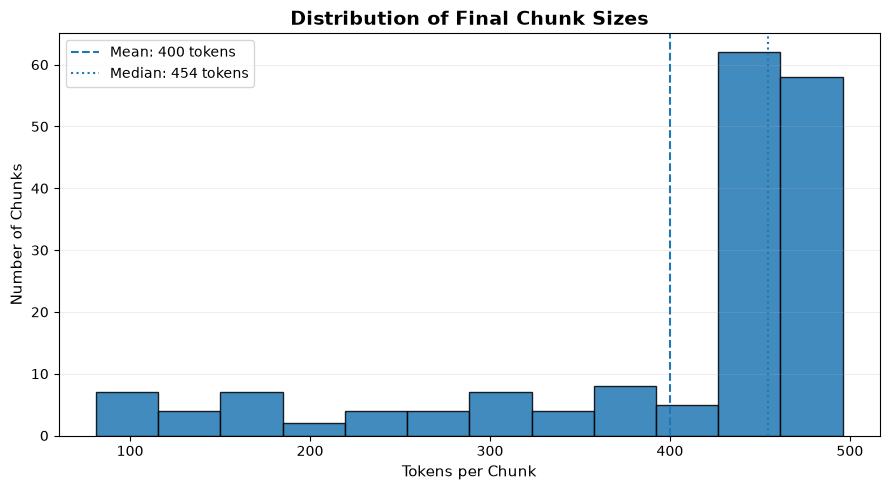

Saved: ../data/processed/protocol_chunks.jsonl
Chunks saved: 172
Chunk size target: 500 tokens
Chunk overlap target: 75 tokens


In [20]:
import matplotlib.pyplot as plt


# Visualise the token-size distribution of the final chunks
plt.figure(figsize=(9, 5))

plt.hist(
    final_chunks_df["token_count"],
    bins=12,
    edgecolor="black",
    alpha=0.85,
)

# Calculate the mean and median chunk sizes
mean_chunk_tokens = final_chunks_df["token_count"].mean()
median_chunk_tokens = final_chunks_df["token_count"].median()

# Show the mean chunk size
plt.axvline(
    mean_chunk_tokens,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_chunk_tokens:.0f} tokens",
)

# Show the median chunk size
plt.axvline(
    median_chunk_tokens,
    linestyle=":",
    linewidth=1.5,
    label=f"Median: {median_chunk_tokens:.0f} tokens",
)

# Make the chart clear and portfolio-friendly
plt.title(
    "Distribution of Final Chunk Sizes",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Tokens per Chunk", fontsize=11)
plt.ylabel("Number of Chunks", fontsize=11)

plt.grid(axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


# Save the final retrieval-ready chunk dataset
chunks_path = Path("../data/processed/protocol_chunks.jsonl")

final_chunks_df.to_json(
    chunks_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Saved:", chunks_path)
print("Chunks saved:", len(final_chunks_df))
print("Chunk size target: 500 tokens")
print("Chunk overlap target: 75 tokens")

## Day 2 Findings

The validated protocol page corpus from Day 1 was cleaned conservatively and converted into retrieval-ready text chunks.

Cleaning focused only on clear PDF extraction artifacts. Detached word breaks such as `coun - selling` and `effi - cacy` were repaired, non-breaking spaces were normalised, and repeated `Page X of Y` labels were removed because page provenance is already stored separately in metadata. Ambiguous hyphenation and other uncertain formatting were intentionally left unchanged to avoid corrupting the source text.

Two page-contained chunking strategies were compared:

- Configuration A: 500-token target with 75-token overlap
- Configuration B: 750-token target with 100-token overlap

Configuration A created 172 chunks, while Configuration B created 117 chunks. The larger Configuration B chunks contained more surrounding context and produced fewer small page-tail chunks, but manual inspection showed that they also began combining more distinct topics within the same retrieval unit.

Configuration A was therefore selected as the provisional strategy because its smaller chunks were more focused for evidence retrieval. This is especially important for a system designed to return precise protocol information with page-level citations.

The final chunk dataset contains:

- 172 chunks
- 5 source documents
- all 52 source pages represented
- 0 empty chunks
- 0 duplicate chunk IDs
- 0 exact duplicate chunk texts
- 0 missing provenance values

All 19 chunks below 200 tokens were confirmed to be final chunks on their source pages. These are expected page-boundary fragments rather than unexplained splitter failures.

The final chunk-size distribution has a mean of approximately 400 tokens and a median of approximately 454 tokens, with most chunks concentrated near the 500-token target.

Each final chunk has a deterministic identifier such as `PROTO_003_P006_C002`, which preserves the source document, PDF page and chunk position. This metadata will later support retrieval inspection, source citations and deterministic citation validation.

The selected 500-token / 75-token-overlap strategy remains provisional until retrieval performance is evaluated. Day 3 will embed these chunks, store them in a vector database and test whether semantic retrieval returns the correct protocol evidence for realistic questions.